# RAW to TIF and Database Loader

Convert one `.raw` UT file to `.tif` next to the RAW file, then load the converted measurement into the database. The RAW filename is expected to contain dimensions as `widthxheightxdepth`, for example `sample_ascan300x295x448.raw`.

In [66]:
from pathlib import Path
import sys

sys.path.append(r'\\192.168.10.110\imdea\DataDriven_UT_AlbertoVicente\10_code\UTvsXCT-preprocessing')
sys.path.append(r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing')

from matplotlib import pyplot as plt

from dbtools import dbtools as db
from dbtools import load
from preprocess_tools import io, signal

## 1. Database connection

In [67]:
try:
    conn = db.connect()
    print("Connected to the database")
except Exception as error:
    print(error)

Connected to the database


## 2. User inputs

In [ ]:
RAW_PATH = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.raw")

# The TIF is saved next to RAW_PATH with only the suffix changed to .tif.
TIF_PATH = RAW_PATH.with_suffix(".tif")

RAW_DTYPE = "uint8"
BYTE_ORDER = "little"
USE_MEMMAP = True
OVERWRITE_TIF = False

# Database metadata. Fill these before running the database-load cell.
MEASUREMENTTYPE_ID = 11  # Example: 11
SAMPLE_NAMES = ['Na_10_1','Na_10_2','Na_10_3','Na_10_4','Na_10_5']          # Example: ["Na_10"]
AXES_ORDER = ["z", "y", "x"] #z is the time dimension
SIGNAL_TYPE = "RF"         # "RF" or "Amplitude"

# Parent measurement is optional and must already exist in the database if provided.
PARENT_MEASUREMENT_PATH = None
TRANSFORMATIONS = None     # Required if PARENT_MEASUREMENT_PATH is set.

# Keep False until the preview cell shows the correct insert parameters.
LOAD_TO_DATABASE = True

## 3. Inspect database options

In [69]:
measurementtypes_table = db.get_data_metadata('measurementtypes')
samples_table = db.get_data_metadata('samples')

display(measurementtypes_table.dropna(axis=1, how='all'))
display(samples_table[['id_sample', 'name_sample']].drop_duplicates().sort_values('name_sample'))

,id_measurementtype,name_measurementtype,description_measurementtype,technique_measurementtype,equipment_measurementtype,transducer_name_measurementtype,transducer_nominal_freq_measurementtype,transducer_diameter_measurementtype,transducer_focal_length_measurementtype,z_resolution_measurementtype,...,projections_measurementtype,target_measurementtype,filter_measurementtype,Detector_measurementtype,scaling_measurementtype,power_measurementtype,DAC_measurementtype,lens_measurementtype,lens_focal_length_measurementtype,transducer_measurementtype
0,5,Monoelement Ultrasound Pulse Echo 1,NaN,Ultrasound Monoelement Pulse Echo nominal,TRITON 1000P nominal,Technisonic ISL-0503-HR nominal,5 MHz,9.525 mm,76.2 mm,0.02232141 mm,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,XCT 1,NaN,X-Ray Computed Tomography nominal,ZEISS Xradia Versa 620 nominal,NaN,NaN,NaN,NaN,NaN,...,3738 cardinal,wolframio nominal,LE1 nominal,Flat Panel nominal,"[-1.700072,1.841701] float array",4.5 W,NaN,NaN,NaN,NaN
2,7,Monoelement Ultrasound Pulse Echo Airbus DAC,NaN,Ultrasound Monoelement Pulse Echo nominal,TRITON 1000P nominal,Technisonic ISL-0503-HR nominal,5 MHz,9.525 mm,76.2 mm,0.02232141 mm,...,NaN,NaN,NaN,NaN,NaN,NaN,"[[10.1,4.33],[12.1,6.18],[19.7,10.38],[26.7,15...",NaN,NaN,NaN
3,8,Monoelement Ultrasound Pulse Echo Low Resolution,NaN,Ultrasound Monoelement Pulse Echo nominal,TRITON 1000P nominal,Technisonic ISL-0503-HR nominal,5 MHz,9.525 mm,76.2 mm,0.05940588 mm,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9,Placeholder Measurement Type,A generic placeholder for a measurement techni...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,Monoelement Ultrasound Pulse Echo Airbus DAC L...,NaN,Ultrasound Monoelement Pulse Echo nominal,TRITON 1000P nominal,Technisonic ISL-0503-HR nominal,5 MHz,9.525 mm,42 mm,0.02232141 mm,...,NaN,NaN,NaN,NaN,NaN,NaN,"[[10.1,4.33],[12.1,6.18],[19.7,10.38],[26.7,15...",True bool,"38,1 mm",NaN
6,11,Monoelement Ultrasound Pulse Echo Na,NaN,Ultrasound Monoelement Pulse Echo nominal,TRITON 1000P nominal,NaN,5 MHz,9.525 mm,76.2 mm,0.02232141 mm,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Technisonic ISL-0503-HR nominal


,id_sample,name_sample
11,20,1.10
12,21,1.11
13,22,1.12
14,23,1.13
15,24,1.14
...,...,...
79,98,Na_10_2
80,99,Na_10_3
81,100,Na_10_4
82,101,Na_10_5


## 4. Convert RAW to TIF

Saved TIF: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.tif


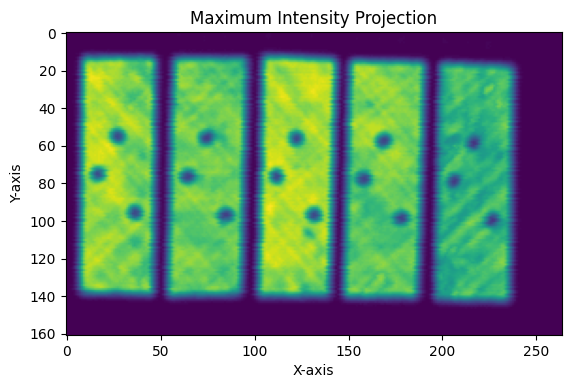

RAW path: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.raw
TIF path: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.tif
Inferred RAW shape (z, y, x): (448, 161, 264)
Loaded TIF shape: (448, 161, 264)
Loaded TIF dtype: uint8


In [70]:
raw_path = Path(RAW_PATH)
tif_path = Path(TIF_PATH)

if tif_path.exists() and not OVERWRITE_TIF:
    print(f"TIF already exists, keeping existing file: {tif_path}")
else:
    saved_path = io.raw_to_tif(
        raw_path,
        tif_path,
        dtype=RAW_DTYPE,
        byte_order=BYTE_ORDER,
        use_memmap=USE_MEMMAP,
    )
    print(f"Saved TIF: {saved_path}")

created_volume = io.load_tif(tif_path)
raw_shape = io.infer_raw_shape(raw_path)

plt.imshow(created_volume.max(axis=0))
plt.title("Maximum Intensity Projection")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

print(f"RAW path: {raw_path}")
print(f"TIF path: {tif_path}")
print(f"Inferred RAW shape (z, y, x): {raw_shape}")
print(f"Loaded TIF shape: {created_volume.shape}")
print(f"Loaded TIF dtype: {created_volume.dtype}")

assert tuple(created_volume.shape) == tuple(raw_shape), f"Shape mismatch: {created_volume.shape} != {raw_shape}"

## 5. Save amplitude volume

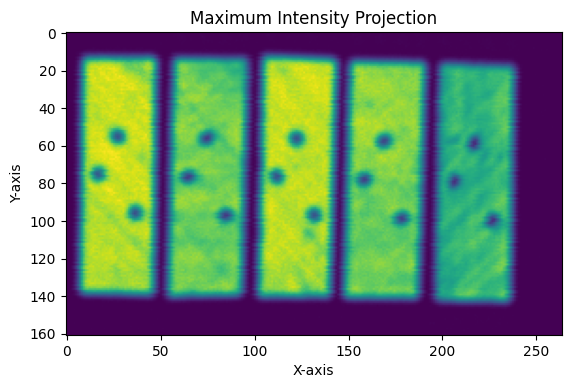

Saved amplitude TIF: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448_amplitude.tif
Amplitude volume shape: (448, 161, 264)
Amplitude volume dtype: float64


In [71]:
amplitude_tif_path = tif_path.with_stem(tif_path.stem + "_amplitude")

amplitude_volume = signal.envelope(created_volume,axis=0)
io.save_tif(amplitude_tif_path, amplitude_volume)

plt.imshow(amplitude_volume.max(axis=0))
plt.title("Maximum Intensity Projection")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

print(f"Saved amplitude TIF: {amplitude_tif_path}")
print(f"Amplitude volume shape: {amplitude_volume.shape}")
print(f"Amplitude volume dtype: {amplitude_volume.dtype}")

## 6. Preview database insert

In [72]:
if MEASUREMENTTYPE_ID is None:
    raise ValueError('Set MEASUREMENTTYPE_ID using the measurementtypes table above.')
if not SAMPLE_NAMES:
    raise ValueError('Set SAMPLE_NAMES using the samples table above.')

height, width, depth = (int(axis) for axis in created_volume.shape)
dtype = str(created_volume.dtype)
file_type = "tif"
parent_measurement_path = None if PARENT_MEASUREMENT_PATH is None else str(PARENT_MEASUREMENT_PATH)
transformations = TRANSFORMATIONS if parent_measurement_path is not None else None

additional_metadata = [
    {'key': 'raw_file_path', 'value': str(raw_path), 'type': 'path'},
    {'key': 'raw_dtype', 'value': str(RAW_DTYPE), 'type': 'nominal'},
    {'key': 'raw_byte_order', 'value': str(BYTE_ORDER), 'type': 'nominal'},
    {'key': 'raw_shape_zyx', 'value': str(tuple(raw_shape)), 'type': 'nominal'},
]

insert_parameters = {
    'file_path': str(tif_path),
    'measurementtype_id': int(MEASUREMENTTYPE_ID),
    'height': height,
    'width': width,
    'depth': depth,
    'dtype': dtype,
    'file_type': file_type,
    'signal_type': SIGNAL_TYPE,
    'sample_names': list(SAMPLE_NAMES),
    'axes_order': list(AXES_ORDER),
    'parent_measurement_path': parent_measurement_path,
    'transformations': transformations,
    'additional_metadata': additional_metadata,
}

measurements_table = db.get_data_metadata('measurements')
existing_rows = measurements_table[measurements_table['file_path_measurement'] == str(tif_path)]
if not existing_rows.empty:
    print('WARNING: This TIF path is already present in the measurements table:')
    display(existing_rows)

insert_parameters

{'file_path': '/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.tif',
 'measurementtype_id': 11,
 'height': 448,
 'width': 161,
 'depth': 264,
 'dtype': 'uint8',
 'file_type': 'tif',
 'signal_type': 'RF',
 'sample_names': ['Na_10_1', 'Na_10_2', 'Na_10_3', 'Na_10_4', 'Na_10_5'],
 'axes_order': ['z', 'y', 'x'],
 'parent_measurement_path': None,
 'transformations': None,
 'additional_metadata': [{'key': 'raw_file_path',
   'value': '/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.raw',
   'type': 'path'},
  {'key': 'raw_dtype', 'value': 'uint8', 'type': 'nominal'},
  {'key': 'raw_byte_order', 'value': 'little', 'type': 'nominal'},
  {'key': 'ra

## 7. Load to database

In [73]:
if not LOAD_TO_DATABASE:
    print('LOAD_TO_DATABASE is False. Review insert_parameters, then set it to True to insert.')
else:
    inserted_id = load.load_ut_measurement(
        conn=conn,
        file_path=insert_parameters['file_path'],
        measurementtype_id=insert_parameters['measurementtype_id'],
        height=insert_parameters['height'],
        width=insert_parameters['width'],
        depth=insert_parameters['depth'],
        dtype=insert_parameters['dtype'],
        file_type=insert_parameters['file_type'],
        signal_type=insert_parameters['signal_type'],
        axes_order=insert_parameters['axes_order'],
        sample_names=insert_parameters['sample_names'],
        parent_measurement_path=insert_parameters['parent_measurement_path'],
        transformations=insert_parameters['transformations'],
        additional_metadata=insert_parameters['additional_metadata'],
    )
    print(f"Inserted measurement id: {inserted_id}")

UT measurement from '/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/5MHz/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms/Na_10_1_2_3_4_5_5MHz_24dB_77mmdistance_10mmrange_20mms_ascan264x161x448.tif' loaded with ID: 542
Inserted measurement id: 542
